# Gaussian Mixture Models (GMM) and the EM Algorithm — A Step-by-Step Walkthrough

In this notebook we will build a Gaussian Mixture Model (GMM) from scratch and train it with the Expectation–Maximization (EM) algorithm, while connecting each step to the underlying theory.

By the end of this notebook, you will be able to:
- Understand the probabilistic model behind GMMs
- Derive and implement the EM updates (E-step and M-step)
- Visualize the learned mixture and interpret convergence
- Discuss practical concerns: initialization, regularization, and model selection (AIC/BIC)

References:
- Slides: `www.intro2ml.com/materials/slides/gmm.pdf`
- Notes: CS229 Lecture Notes on Gaussian Mixture Models


## What is a Gaussian Mixture Model (GMM)?

A Gaussian Mixture Model assumes that data points are generated by a mixture of $K$ Gaussian components. Each component $j$ has parameters:
- Mean $\mu_j \in \mathbb{R}^d$
- Covariance $\Sigma_j \in \mathbb{R}^{d\times d}$ (symmetric positive definite)
- Mixing coefficient $\phi_j$, where $\phi_j \ge 0$ and $\sum_{j=1}^K \phi_j = 1$

The likelihood of a data point $x$ under the mixture is:
$$
 p(x \mid \{\phi_j, \mu_j, \Sigma_j\}_{j=1}^K) = \sum_{j=1}^K \phi_j \; \mathcal{N}(x \mid \mu_j, \Sigma_j).
$$

We introduce latent assignment variables $z^{(i)} \in \{1,\dots,K\}$ (or one-hot $\mathbf{z}_i$) indicating which component generated $x^{(i)}$. The joint distribution factorizes as
$$
 p(x^{(i)}, z^{(i)}=j) = \phi_j \; \mathcal{N}(x^{(i)} \mid \mu_j, \Sigma_j).
$$

See the course slides and notes for visual intuition: mixtures can model multi-modal datasets that a single Gaussian cannot.


## Maximum Likelihood and the EM Algorithm

Given data $\{x^{(i)}\}_{i=1}^n$, we want to maximize the (incomplete) log-likelihood:
$$
 \ell(\Theta) = \sum_{i=1}^n \log \sum_{j=1}^K \phi_j\; \mathcal{N}(x^{(i)}\mid \mu_j, \Sigma_j), \quad \Theta = \{\phi_j, \mu_j, \Sigma_j\}_{j=1}^K.
$$
This objective is non-convex and the log of a sum prevents closed-form maximization. EM solves this by introducing the latent variables and optimizing a lower bound via alternating steps:

- E-step: compute responsibilities (posterior assignments)
$$
 w_j^{(i)} = p(z_i=j \mid x^{(i)}, \Theta^{(t)}) = \frac{\phi_j^{(t)}\, \mathcal{N}(x^{(i)}\mid \mu_j^{(t)}, \Sigma_j^{(t)})}{\sum_{\ell=1}^K \phi_\ell^{(t)}\, \mathcal{N}(x^{(i)}\mid \mu_\ell^{(t)}, \Sigma_\ell^{(t)})}.
$$

- M-step: update parameters using soft counts $N_j = \sum_i w_j^{(i)}$
$$
 \phi_j^{(t+1)} = \frac{N_j}{n},\quad
 \mu_j^{(t+1)} = \frac{1}{N_j} \sum_{i=1}^n w_j^{(i)} x^{(i)},\quad
 \Sigma_j^{(t+1)} = \frac{1}{N_j} \sum_{i=1}^n w_j^{(i)} (x^{(i)}-\mu_j^{(t+1)})(x^{(i)}-\mu_j^{(t+1)})^\top.
$$

Each iteration increases the log-likelihood until convergence to a local optimum.


## Setup and Data Generation
We begin by generating a synthetic 2D dataset from three Gaussian clusters, similar to the script version. We will then fit a 3-component GMM.


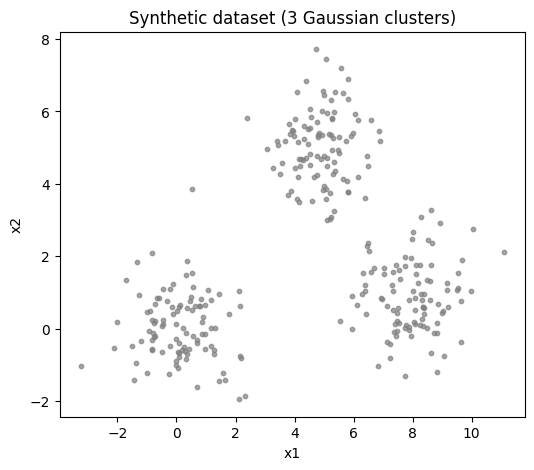

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Reproducibility
np.random.seed(42)

# Generate synthetic data from 3 Gaussian distributions
mean1, cov1 = np.array([5.0, 5.0]), np.array([[1.0, 0.0], [0.0, 1.0]])
mean2, cov2 = np.array([0.0, 0.0]), np.array([[1.0, 0.0], [0.0, 1.0]])
mean3, cov3 = np.array([8.0, 1.0]), np.array([[1.0, 0.0], [0.0, 1.0]])

n_per = 100
X1 = np.random.multivariate_normal(mean1, cov1, n_per)
X2 = np.random.multivariate_normal(mean2, cov2, n_per)
X3 = np.random.multivariate_normal(mean3, cov3, n_per)

X = np.vstack([X1, X2, X3])
N, D = X.shape
K = 3

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=10, c='gray', alpha=0.7)
plt.title('Synthetic dataset (3 Gaussian clusters)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


## Initialization and Utilities
We initialize the mixture parameters and set up helper functions for evaluating Gaussians and plotting learned components.


In [2]:
# Initialization
phi = np.ones(K) / K
mu = np.random.rand(K, D) * 10.0
Sigma = np.array([np.eye(D) for _ in range(K)])

# Visualization grid for contours
xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
pos = np.dstack((xg, yg))


def plot_gmm(X, mu, Sigma, title='GMM Contours', colors=('r','g','b')):
    plt.figure(figsize=(4, 4))
    plt.scatter(X[:, 0], X[:, 1], s=10, color='grey', label='Data Points', alpha=0.6)
    for j in range(K):
        rv = multivariate_normal(mean=mu[j], cov=Sigma[j], allow_singular=False)
        plt.contour(xg, yg, rv.pdf(pos), levels=5, colors=colors[j], alpha=0.8)
        plt.scatter(*mu[j], c=colors[j], marker='x', s=100, label=f'Mean {j+1}')
    plt.title(title)
    plt.xlim(-5, 15)
    plt.ylim(-5, 15)
    plt.legend()
    plt.show()


## E-step: Expectation step - Updating the Responsibilities
We compute responsibilities $w_j^{(i)} = p(z^{(i)}=j\mid x^{(i)}, \Theta)$. Numerically, we normalize the component likelihoods across $j$ for each $i$.


In [3]:
def e_step(X, phi, mu, Sigma):
    N, K = X.shape[0], phi.shape[0]
    W = np.zeros((N, K))
    for j in range(K):
        W[:, j] = phi[j] * multivariate_normal(mean=mu[j], cov=Sigma[j]).pdf(X)
    # Normalize to get responsibilities
    W_sum = W.sum(axis=1, keepdims=True)
    W_sum[W_sum == 0.0] = 1e-16
    W /= W_sum
    return W


## M-step: Parameter Updates
Given responsibilities, compute soft counts $N_j$, mixing weights $\phi_j$, means $\mu_j$, and covariances $\Sigma_j$.


In [4]:
def m_step(X, W):
    N, D = X.shape
    K = W.shape[1]
    Nk = W.sum(axis=0)  # soft counts

    # Update mixing coefficients
    phi_new = Nk / N

    # Update means
    mu_new = (W.T @ X) / Nk[:, None]

    # Update covariances
    Sigma_new = np.zeros((K, D, D))
    for j in range(K):
        diff = X - mu_new[j]
        # weight each outer product by responsibility
        Sigma_new[j] = (W[:, j][:, None] * diff).T @ diff / Nk[j]
        # regularization for numerical stability (optional, small jitter)
        Sigma_new[j] += 1e-8* np.eye(D)

    return phi_new, mu_new, Sigma_new


## Monitoring Convergence: Log-Likelihood
We track the data log-likelihood under the current mixture. EM guarantees non-decreasing log-likelihood across iterations.


In [5]:
def log_likelihood(X, phi, mu, Sigma):
    N, K = X.shape[0], phi.shape[0]
    comp = np.zeros((N, K))
    for j in range(K):
        comp[:, j] = phi[j] * multivariate_normal(mean=mu[j], cov=Sigma[j]).pdf(X)
    # sum over components then take log
    s = comp.sum(axis=1)
    s[s == 0.0] = 1e-30
    return np.sum(np.log(s))


## Run EM
We now alternate E and M steps until the log-likelihood stabilizes or the maximum number of iterations is reached. We also visualize contours at selected iterations.


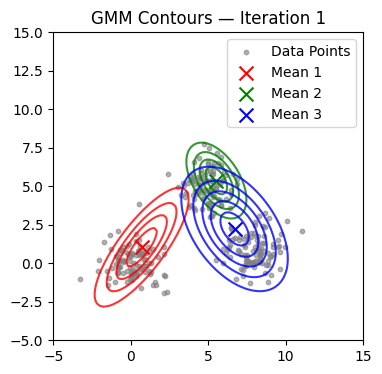

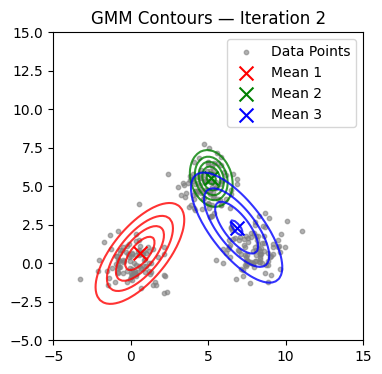

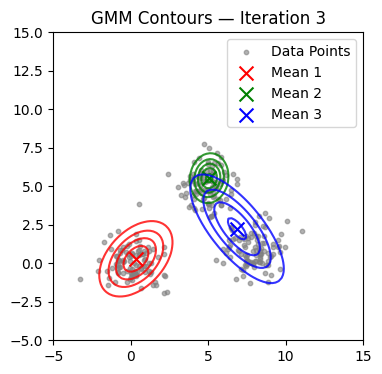

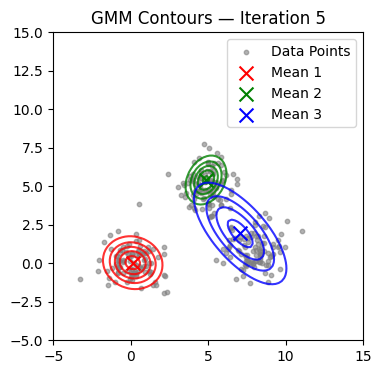

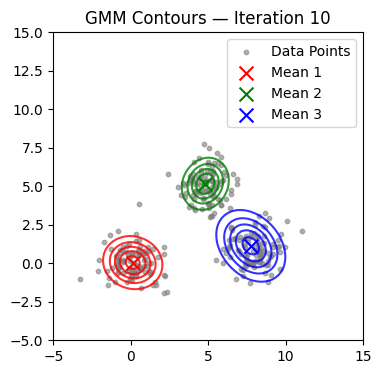

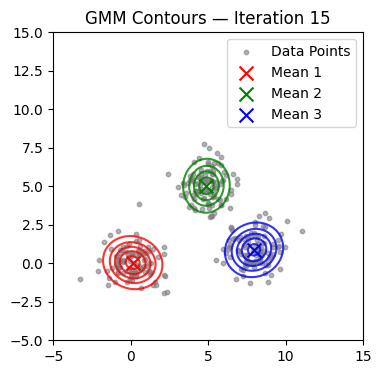

Converged at iteration 18


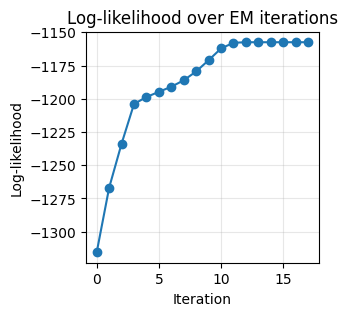

In [6]:
max_iter = 300
tol = 1e-9
lls = []

for it in range(max_iter):
    # E-step
    W = e_step(X, phi, mu, Sigma)

    # M-step
    phi, mu, Sigma = m_step(X, W)

    # Log-likelihood
    ll = log_likelihood(X, phi, mu, Sigma)
    lls.append(ll)

    # Visualization every few iterations
    if it in (0, 1, 2, 4, 9, 14, 19, 24, 29):
        plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')

    # Convergence check
    if it > 0 and abs(lls[-1] - lls[-2]) < tol:
        print(f'Converged at iteration {it+1}')
        break

plt.figure(figsize=(3,3))
plt.plot(lls, marker='o')
plt.title('Log-likelihood over EM iterations')
plt.xlabel('Iteration')
plt.ylabel('Log-likelihood')
plt.grid(True, alpha=0.3)
plt.show()


## Practical Notes: Initialization, Regularization, and Model Selection

- Initialization: k-means centroids as initial $\mu_j$, uniform or cluster-proportional $\phi_j$, and empirical covariances often speed up convergence and improve stability. Random initialization can lead to poor local optima.
- Regularization: add a small diagonal jitter to each $\Sigma_j$ to avoid singularities when clusters collapse.
- Model selection: compare different $K$ using AIC or BIC. For a model with parameter count $p$:
  - AIC = $-2\,\ell(\hat{\Theta}) + 2p$
  - BIC = $-2\,\ell(\hat{\Theta}) + p\,\log n$
- Multiple restarts: run EM from several random initializations and keep the solution with highest final log-likelihood.
- Constraints: diagonal or spherical covariances can reduce overfitting and computation.
